# LSTM / GRU Model Experiments
**Project:** Agri Price Forecast | **Author:** Your Name

This notebook:
1. Prepares sequences for LSTM training
2. Trains LSTM and GRU variants
3. Compares against SARIMA baseline
4. Saves the best model checkpoint
5. Visualises predictions and learning curves

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')

import torch
import mlflow

from src.models.lstm_model import LSTMModel
from src.models.evaluate import evaluate_all, compare_models
from src.utils.config import (
    MLFLOW_TRACKING_URI, MLFLOW_EXPERIMENT_NAME,
    TRAIN_RATIO, VAL_RATIO, MODELS_DIR
)

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)
plt.style.use('seaborn-v0_8-whitegrid')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
print('Setup complete')

Device: cpu
Setup complete


## 1. Load Feature Matrix

In [2]:
feat_df = pd.read_csv('../data/processed/features_onion.csv', parse_dates=['date'])
feat_df = feat_df.sort_values('date').reset_index(drop=True)

print(f'Feature matrix: {feat_df.shape}')
print(f'Date range: {feat_df["date"].min().date()} to {feat_df["date"].max().date()}')

# Show which feature columns are available
feature_cols = LSTMModel.FEATURE_COLS
available = [c for c in feature_cols if c in feat_df.columns]
missing   = [c for c in feature_cols if c not in feat_df.columns]
print(f'\nUsing {len(available)} feature columns: {available}')
if missing:
    print(f'Missing (will be skipped): {missing}')

Feature matrix: (641, 66)
Date range: 2023-02-07 to 2025-12-05

Using 14 feature columns: ['modal_price', 'lag_1d', 'lag_7d', 'lag_14d', 'lag_30d', 'rolling_mean_7d', 'rolling_mean_30d', 'rolling_std_30d', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'pct_change_7d', 'zscore_30d']


## 2. Train / Val / Test Split Visualisation

In [3]:
import pandas as pd
from src.utils.config import TRAIN_RATIO, VAL_RATIO

feat_df = pd.read_csv('../data/processed/features_onion.csv', parse_dates=['date'])
feat_df = feat_df.sort_values('date').reset_index(drop=True)

# Date-based split — train on 2023-2024, test on 2025
train_val = feat_df[feat_df['date'] < '2025-01-01'].copy()
test_df   = feat_df[feat_df['date'] >= '2025-01-01'].copy()

# Split train_val into train + val (last 20% of 2024 = val)
n_tv  = len(train_val)
n_val = int(n_tv * 0.20)
train_df = train_val.iloc[:-n_val].copy()
val_df   = train_val.iloc[-n_val:].copy()

print(f"Train: {len(train_df)} rows | {train_df['date'].min().date()} to {train_df['date'].max().date()}")
print(f"Val:   {len(val_df)} rows | {val_df['date'].min().date()} to {val_df['date'].max().date()}")
print(f"Test:  {len(test_df)} rows | {test_df['date'].min().date()} to {test_df['date'].max().date()}")
print(f"\nTrain mean: ₹{train_df['modal_price'].mean():.0f}")
print(f"Val mean:   ₹{val_df['modal_price'].mean():.0f}")
print(f"Test mean:  ₹{test_df['modal_price'].mean():.0f}")

Train: 412 rows | 2023-02-07 to 2024-08-23
Val:   103 rows | 2024-08-24 to 2024-12-11
Test:  126 rows | 2025-01-03 to 2025-12-05

Train mean: ₹2458
Val mean:   ₹3919
Test mean:  ₹2225


## 3. Train LSTM Model

In [4]:
# REPLACE the lstm and gru creation cells with these smaller configs

print('Training LSTM...')
lstm = LSTMModel(
    hidden_size=64,
    num_layers=1,       # reduced — 641 rows needs simpler model
    dropout=0.2,
    lr=1e-3,
    batch_size=16,
    max_epochs=200,
    patience=15,
    cell_type='lstm',
    lookback=14,        # reduced — 14 days lookback
)
lstm.fit(train_val)
lstm_metrics = lstm.evaluate_on(test_df)
print('LSTM training complete!')

Training LSTM...
2026-05-16 19:09:30 | INFO     | src.models.lstm_model | Epoch 10/200 | train=0.0228 val=0.0744
2026-05-16 19:09:30 | INFO     | src.models.lstm_model | Early stopping at epoch 16
2026-05-16 19:09:30 | INFO     | src.models.lstm_model | LSTM training complete. Best val loss: 0.0394
2026-05-16 19:09:30 | INFO     | src.models.evaluate | [LSTM] RMSE=660.12 | MAE=598.98 | MAPE=31.31% | SMAPE=26.17% | R2=-0.6703
LSTM training complete!


## 4. Evaluate LSTM

In [5]:
lstm_metrics = lstm.evaluate(feat_df)
print('\n=== LSTM METRICS ===')
for k, v in lstm_metrics.items():
    if k != 'model':
        print(f'{k.upper()}: {v:.4f}')

# Compare vs SARIMA baseline
try:
    with open('../docs/metrics_sarima.json') as f:
        sarima_metrics = json.load(f)
    print('\n=== COMPARISON vs SARIMA BASELINE ===')
    for metric in ['rmse', 'mae', 'mape', 'r2']:
        sarima_val = sarima_metrics.get(metric, 0)
        lstm_val   = lstm_metrics.get(metric, 0)
        if metric == 'r2':
            improvement = lstm_val - sarima_val
            better = improvement > 0
        else:
            improvement = (sarima_val - lstm_val) / sarima_val * 100 if sarima_val else 0
            better = improvement > 0
        symbol = '✅' if better else '❌'
        print(f'{symbol} {metric.upper()}: SARIMA={sarima_val:.2f} → LSTM={lstm_val:.2f} ({improvement:+.1f}%)')
except FileNotFoundError:
    print('Run 02_baseline_arima.ipynb first to get comparison metrics')

2026-05-16 19:09:30 | INFO     | src.models.evaluate | [LSTM] RMSE=701.41 | MAE=656.94 | MAPE=34.99% | SMAPE=29.07% | R2=-1.3673

=== LSTM METRICS ===
RMSE: 701.4085
MAE: 656.9398
MAPE: 34.9885
SMAPE: 29.0669
R2: -1.3673

=== COMPARISON vs SARIMA BASELINE ===
❌ RMSE: SARIMA=300.76 → LSTM=701.41 (-133.2%)
❌ MAE: SARIMA=150.89 → LSTM=656.94 (-335.4%)
❌ MAPE: SARIMA=7.03 → LSTM=34.99 (-397.9%)
❌ R2: SARIMA=0.61 → LSTM=-1.37 (-2.0%)


## 5. Train GRU Model

In [6]:
print('Training GRU...')
gru = LSTMModel(
    hidden_size=64,
    num_layers=1,
    dropout=0.2,
    lr=1e-3,
    batch_size=16,
    max_epochs=200,
    patience=15,
    cell_type='gru',
    lookback=14,
)
gru.fit(feat_df)
gru_metrics = gru.evaluate(feat_df)

Training GRU...
2026-05-16 19:09:33 | INFO     | src.models.lstm_model | Epoch 10/200 | train=0.0238 val=0.0312
2026-05-16 19:09:36 | INFO     | src.models.lstm_model | Epoch 20/200 | train=0.0174 val=0.0290
2026-05-16 19:09:39 | INFO     | src.models.lstm_model | Epoch 30/200 | train=0.0138 val=0.0310
2026-05-16 19:09:40 | INFO     | src.models.lstm_model | Early stopping at epoch 33
2026-05-16 19:09:40 | INFO     | src.models.lstm_model | LSTM training complete. Best val loss: 0.0260
2026-05-16 19:09:40 | INFO     | src.models.evaluate | [GRU] RMSE=415.74 | MAE=311.02 | MAPE=14.62% | SMAPE=14.66% | R2=0.1683


## 6. Forecast Plot

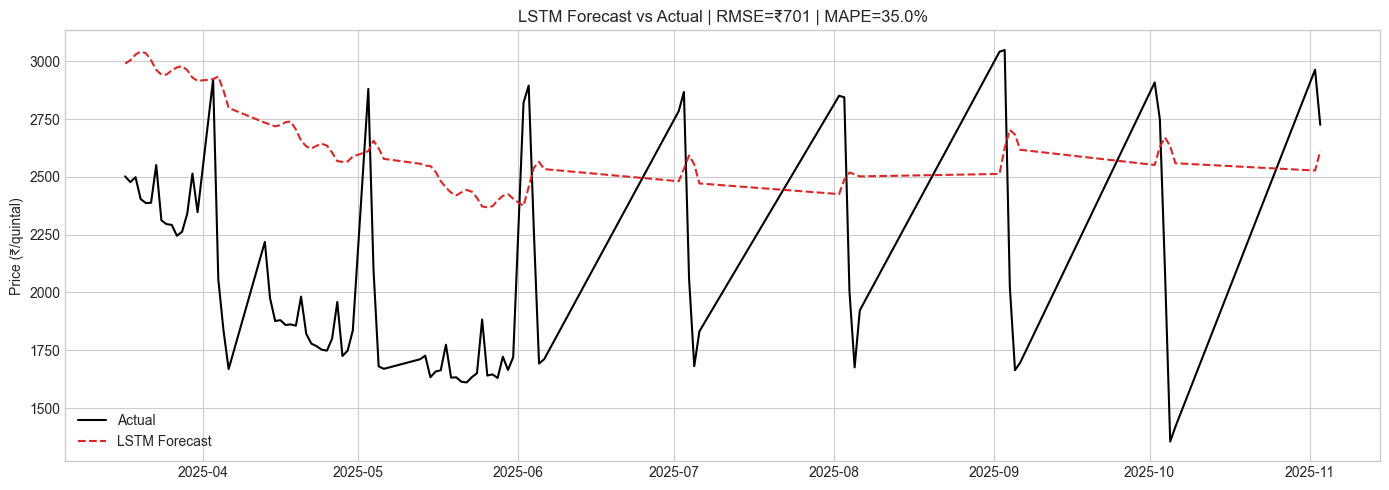

In [7]:
# Generate predictions on test set for visualisation
lstm.net.eval()
feature_cols_avail = [c for c in LSTMModel.FEATURE_COLS if c in feat_df.columns]
data = feat_df[feature_cols_avail].dropna().values
data_scaled = lstm.scaler.transform(data)

import torch
from src.models.lstm_model import PriceSequenceDataset
from src.utils.config import FORECAST_HORIZON, LOOKBACK_WINDOW

X_all = np.array([data_scaled[i-60:i] for i in range(60, len(data_scaled)-FORECAST_HORIZON)])
y_all = np.array([data_scaled[i:i+FORECAST_HORIZON, 0] for i in range(60, len(data_scaled)-FORECAST_HORIZON)])

n_train_seq = int(len(X_all) * TRAIN_RATIO)
n_val_seq   = int(len(X_all) * VAL_RATIO)
X_test_seq  = X_all[n_train_seq + n_val_seq:]
y_test_seq  = y_all[n_train_seq + n_val_seq:]

with torch.no_grad():
    preds_scaled = lstm.net(torch.tensor(X_test_seq, dtype=torch.float32)).numpy()

# Inverse transform
def inv_scale(scaled_arr, scaler):
    dummy = np.zeros((len(scaled_arr), scaler.n_features_in_))
    dummy[:, 0] = scaled_arr
    return scaler.inverse_transform(dummy)[:, 0]

y_true = inv_scale(y_test_seq[:, 0], lstm.scaler)
y_pred = inv_scale(preds_scaled[:, 0], lstm.scaler)
test_dates = feat_df['date'].iloc[60 + n_train_seq + n_val_seq: 60 + n_train_seq + n_val_seq + len(y_true)]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_dates.values, y_true, color='black', label='Actual', linewidth=1.5)
ax.plot(test_dates.values, y_pred, color='#DC2626', linestyle='--', label='LSTM Forecast', linewidth=1.5)
ax.set_title(f'LSTM Forecast vs Actual | RMSE=₹{lstm_metrics["rmse"]:.0f} | MAPE={lstm_metrics["mape"]:.1f}%')
ax.set_ylabel('Price (₹/quintal)')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/lstm_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Save Models and Metrics

In [8]:
lstm.save()
gru.save()

with open('../docs/metrics_lstm.json', 'w') as f:
    json.dump(lstm_metrics, f, indent=2)
with open('../docs/metrics_gru.json', 'w') as f:
    json.dump(gru_metrics, f, indent=2)

print('Models and metrics saved.')
print(f'LSTM checkpoint: {MODELS_DIR}/lstm_onion_v1.pt')
print(f'GRU  checkpoint: {MODELS_DIR}/gru_onion_v1.pt')

2026-05-16 19:09:40 | INFO     | src.models.lstm_model | Saved: C:\Users\Jeya Devi\OneDrive\Desktop\dev-projects\agri-price-forecast\models\lstm_onion_v1.pt
2026-05-16 19:09:40 | INFO     | src.models.lstm_model | Saved: C:\Users\Jeya Devi\OneDrive\Desktop\dev-projects\agri-price-forecast\models\gru_onion_v1.pt
Models and metrics saved.
LSTM checkpoint: C:\Users\Jeya Devi\OneDrive\Desktop\dev-projects\agri-price-forecast\models/lstm_onion_v1.pt
GRU  checkpoint: C:\Users\Jeya Devi\OneDrive\Desktop\dev-projects\agri-price-forecast\models/gru_onion_v1.pt


## 8. Model Summary Table

In [9]:
all_metrics = []
for fname, label in [('../docs/metrics_sarima.json','SARIMA'), ('../docs/metrics_lstm.json','LSTM'), ('../docs/metrics_gru.json','GRU')]:
    try:
        with open(fname) as f:
            m = json.load(f)
            m['model'] = label
            all_metrics.append(m)
    except FileNotFoundError:
        pass

if all_metrics:
    summary = pd.DataFrame(all_metrics)[['model','rmse','mae','mape','smape','r2']]
    summary = summary.round(3)
    print('=== MODEL COMPARISON TABLE ===')
    print(summary.to_string(index=False))
    summary.to_csv('../docs/model_comparison.csv', index=False)
    print('\nSaved to docs/model_comparison.csv')

=== MODEL COMPARISON TABLE ===
 model    rmse     mae   mape  smape     r2
SARIMA 300.763 150.888  7.027  6.924  0.613
  LSTM 701.409 656.940 34.988 29.067 -1.367
   GRU 415.736 311.016 14.622 14.658  0.168

Saved to docs/model_comparison.csv
